In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt 
plt.rcParams['figure.figsize'] = [16, 12]

# Newton-Raphson Method

### The notebook implement the Newton-Raphson solver and uses it on two functions: 
$$ f_1(x) = -\frac{x}{\sigma^2} e^{-\frac{x^2}{2\sigma^2}},\quad \sigma = 1.$$
$$ f_2((x) = 1.45469 − 3.46032x − 0.272173x^2 + 0.186534x^3 − 0.0022172x^4 − 0.00156431x^5.$$

In [ ]:
def f1(x, sigma=1.0):
    """ First function from the assignment"""
    return - x * np.exp(-x**2/(2*sigma**2)) / (sigma**2)

def df1(x, sigma=1.0):
    """ Derivative of the first function from the assignment"""
    return np.exp(-x**2/(2*sigma**2)) * (x**2 - sigma**2) / sigma**4

def ddf1(x, sigma=1.0):
    """ Second derivative of the first function from the assignment"""
    return np.exp(-x**2/(2*sigma**2)) * x * (3*sigma**2 - x**2) / sigma**6

def f2(x):
    """ Second function from the assignment"""
    return 1.45469 - 3.46032 * x - 0.272173 * x**2 + 0.186534 * x**3 - 0.0022172 * x**4 - 0.00156431 * x**5

def df2(x):
    """ Derivative of the second function from the assignment"""
    return -3.46032 - 2 * 0.272173 * x + 3 * 0.186534 * x**2 - 4 * 0.0022172 * x**3 - 5 * 0.00156431 * x**4

def ddf2(x):
    """ Second derivative of the second function from the assignment"""
    return -2 * 0.272173 + 6 * 0.186534 * x - 12 * 0.0022172 * x**2 - 20 * 0.00156431 * x**3

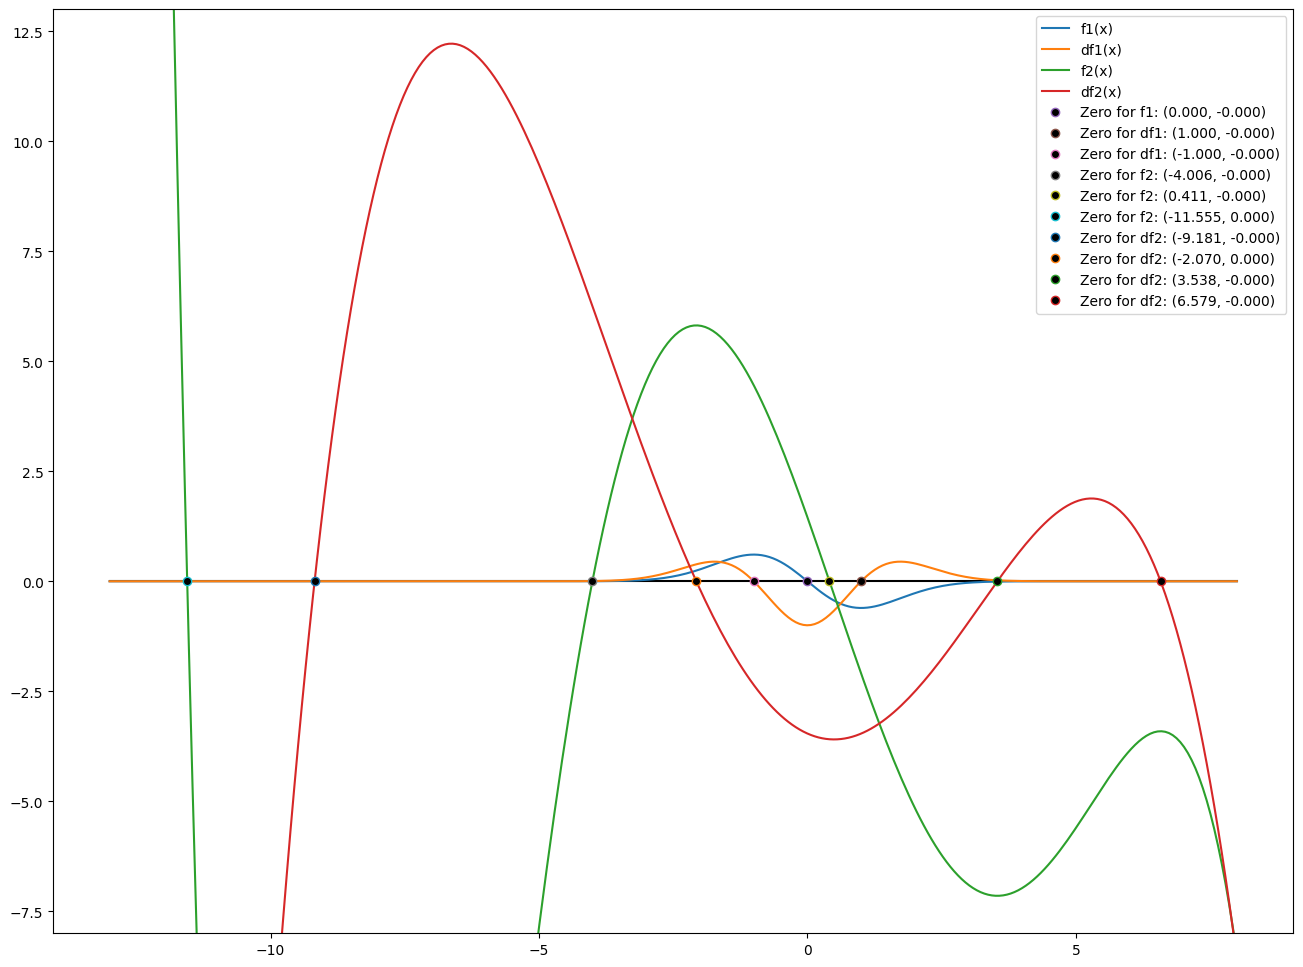

In [190]:
def NewtonRaphson(f, df, x0, tol=1e-8, maxiters=100) :
    """ Newton-Raphson method for finding roots of f(x) = 0"""
    
    # setup variables
    xn = x0
    xn_prev = x0
    n = 0
    
    # run loop endlessly until one of the stop conditions is met
    while True:
        
        # stop if the absolute value of the derivitive of xn is too close to zero
        if abs(df(xn)) < tol:
            break
        
        # update the previous xn to be the current xn
        xn_prev = xn
    
        # update xn to be the the new xn
        xn = xn - f(xn) / df(xn)
        
        # add one to n
        n += 1
    
        # stops if f(xn) gets too close to zero or if the absolute value of xn - xn_prev is too close to zero
        # or if there are too mant digits
        if abs(f(xn)) < tol or abs(xn - xn_prev) < tol or n >= maxiters:
            break
    
    # return the computed value
    return xn

# zero for f1
f1_x1 = NewtonRaphson(f1,df1,0.5)

# zeros for df1
df1_x1 = NewtonRaphson(df1, ddf1, 0.5)
df1_x2 = NewtonRaphson(df1, ddf1, -0.5)

# zeros for f2
f2_x1 = NewtonRaphson(f2, df2, 3)
f2_x2 = NewtonRaphson(f2, df2, 4)
f2_x3 = NewtonRaphson(f2, df2, 10)

# zeros for df2
df2_x1 = NewtonRaphson(df2, ddf2, -7)
df2_x2 = NewtonRaphson(df2, ddf2, -2)
df2_x3= NewtonRaphson(df2, ddf2, 2)
df2_x4 = NewtonRaphson(df2, ddf2, 5)

# sets up the system, with x and y limits
x = np.linspace(-13, 8, 300)
plt.ylim(-8, 13)

# plot the x-axis
plt.plot(x, np.zeros_like(x), color="black")

# plot the functions
plt.plot(x, f1(x), label="f1(x)")
plt.plot(x, df1(x), label="df1(x)")
plt.plot(x, f2(x), label="f2(x)")
plt.plot(x, df2(x), label="df2(x)")

# plot the zero for f1
plt.plot(f1_x1, f1(f1_x1), 'o', markerfacecolor='black', label=f"Zero for f1: ({float(f1_x1):.3f}, {float(f1(f1_x1)):.3f})")

# plot the zeros for df1
plt.plot(df1_x1, df1(df1_x1), 'o', markerfacecolor='black', label=f"Zero for df1: ({float(df1_x1):.3f}, {float(df1(df1_x1)):.3f})")
plt.plot(df1_x2, df1(df1_x2), 'o', markerfacecolor='black', label=f"Zero for df1: ({float(df1_x2):.3f}, {float(df1(df1_x2)):.3f})")

# plot the zeros for f2
plt.plot(f2_x1, f2(f2_x1), 'o', markerfacecolor='black', label=f"Zero for f2: ({float(f2_x1):.3f}, {float(f2(f2_x1)):.3f})")
plt.plot(f2_x2, f2(f2_x2), 'o', markerfacecolor='black', label=f"Zero for f2: ({float(f2_x2):.3f}, {float(f2(f2_x2)):.3f})")
plt.plot(f2_x3, f2(f2_x3), 'o', markerfacecolor='black', label=f"Zero for f2: ({float(f2_x3):.3f}, {float(f2(f2_x3)):.3f})")

# plot the zeros for df2
plt.plot(df2_x1, df2(df2_x1), 'o', markerfacecolor='black', label=f"Zero for df2: ({float(df2_x1):.3f}, {float(df2(df2_x1)):.3f})")
plt.plot(df2_x2, df2(df2_x2), 'o', markerfacecolor='black', label=f"Zero for df2: ({float(df2_x2):.3f}, {float(df2(df2_x2)):.3f})")
plt.plot(df2_x3, df2(df2_x3), 'o', markerfacecolor='black', label=f"Zero for df2: ({float(df2_x3):.3f}, {float(df2(df2_x3)):.3f})")
plt.plot(df2_x4, df2(df2_x4), 'o', markerfacecolor='black', label=f"Zero for df2: ({float(df2_x4):.3f}, {float(df2(df2_x4)):.3f})")

plt.legend()